## CNN CIA Test 1
### Instructions
**Marks: 15**
- Identify and correct the errors without completely rewriting the program.
- Execute the corrected program successfully.

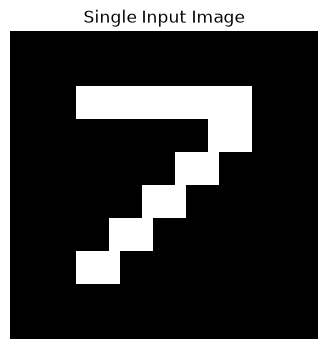

Input shape: (1, 28, 28, 1)
Minimum: 0.0
Maximum: 1.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 10, 10, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │        51,232 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 70,560 (275.62 KB)

 Trainable params: 70,560 (275.62 KB)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step

Final feature representation shape: (1, 32)
Forward pass completed successfully.
First convolution output shape: (1, 24, 24, 32)


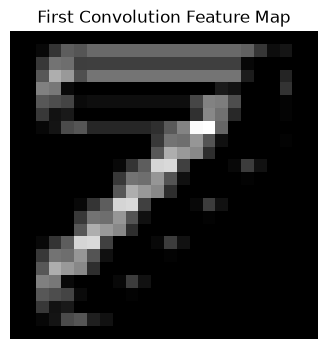

In [1]:
import numpy as np
import tensorflow as tf  # FIX: code uses the tf alias
import matplotlib.pyplot as plt

# ============================================================
# CNN DEBUGGING TEST
# ============================================================

# Create one local 28 x 28 grayscale image
image = np.zeros((28, 28, 1), dtype=np.float32)

image[5:8, 6:22] = 1.0
image[8:11, 18:22] = 1.0
image[11:14, 15:19] = 1.0
image[14:17, 12:16] = 1.0
image[17:20, 9:13] = 1.0
image[20:23, 6:10] = 1.0

# Display the input image
plt.figure(figsize=(4, 4))
plt.imshow(image[:, :, 0], cmap="gray")  # FIX: imshow needs a 2-D (28, 28) array
plt.title("Single Input Image")
plt.axis("off")
plt.show()

# Normalize the image
image = image / image.max()  # FIX: scale into [0, 1]; * 255 pushed values to 255

# Add batch dimension
image = image.reshape(1, 28, 28, 1)  # FIX: (batch, height, width, channels)

print("Input shape:", image.shape)
print("Minimum:", image.min())
print("Maximum:", image.max())

# ============================================================
# CNN MODEL
# ============================================================

model = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28, 1)),  # FIX: input needs the channel axis (28, 28, 1)

    tf.keras.layers.Conv2D(
        filters=32,
        kernel_size=(5, 5),
        activation="relu"  # FIX: ReLU instead of sigmoid in hidden layers
    ),

    tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2),  # FIX: standard 2 x 2 pooling
        strides=(2, 2)
    ),

    tf.keras.layers.Conv2D(
        filters=64,  # FIX: filters grow with depth (32 -> 64)
        kernel_size=(3, 3),
        activation="relu"  # FIX: ReLU
    ),

    tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    tf.keras.layers.Flatten(),  # FIX: layer must be instantiated, missing comma

    tf.keras.layers.Dense(
        32,
        activation="relu"  # FIX: ReLU
    )
])

model.summary()

# ============================================================
# FORWARD PASS
# ============================================================

output = model.predict(image)

print("\nFinal feature representation shape:", output.shape)
print("Forward pass completed successfully.")

# ============================================================
# FIRST CONVOLUTION FEATURE MAP
# ============================================================

feature_model = tf.keras.Model(
    inputs=model.inputs[0],  # FIX: Keras 3 Sequential has no usable .input
    outputs=model.layers[0].output  # FIX: layers[0] is the first Conv2D (layers[2] is the second)
)

feature_maps = feature_model(image, training=False)

print("First convolution output shape:", feature_maps.shape)

plt.figure(figsize=(5, 4))
plt.imshow(feature_maps[0, :, :, 0], cmap="gray")
plt.title("First Convolution Feature Map")
plt.axis("off")
plt.show()
